In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings


warnings.filterwarnings('ignore')

#Data Read
file_path = 'heart_disease_uci.csv'
df = pd.read_csv(file_path, na_values='?')


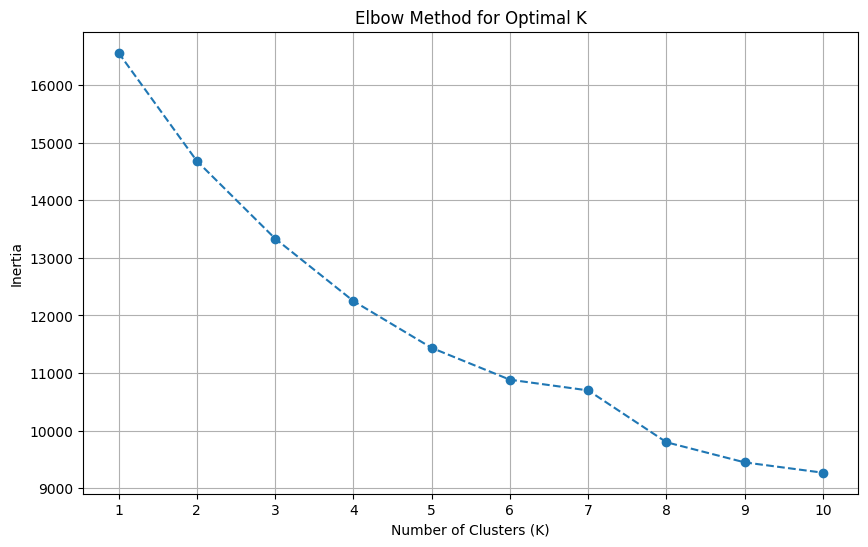

Reducing data to 2 dimensions using PCA for visualization...


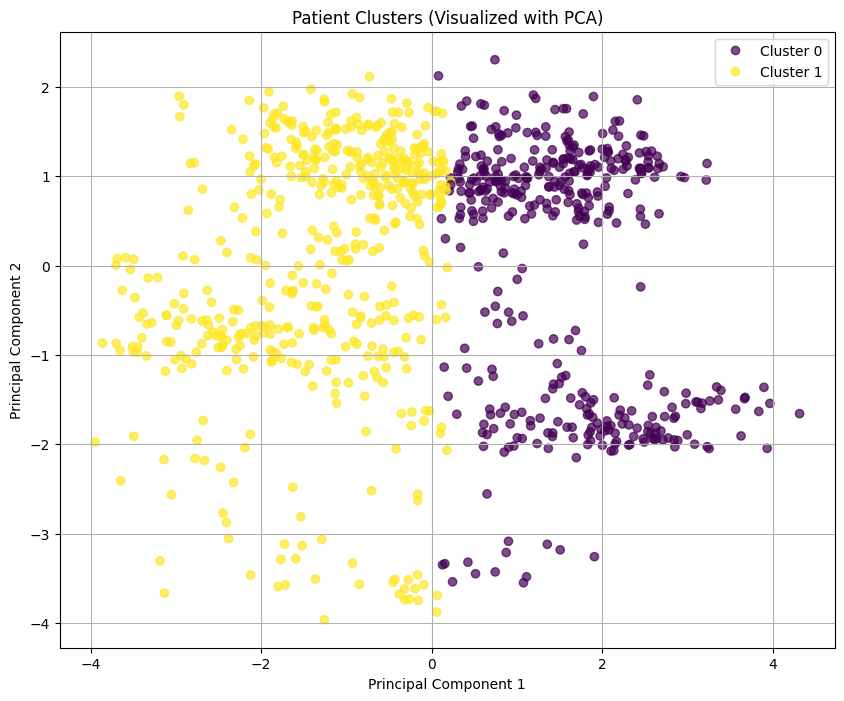

-----------------------------------------
Comparing Cluster Labels 
-----------------------------------------
Cluster Label    0    1
Actual Label           
0              317   94
1               97  412

This table shows how the patients from the actual target classes (0 and 1) were grouped into clusters.


In [ ]:
#Handle Missing Values
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object':
            mode_value = df[col].mode()[0]
            df[col].fillna(mode_value, inplace=True)
        else:
            mean_value = df[col].mean()
            df[col].fillna(mean_value, inplace=True)

# Data Encoding
df_processed = df.drop(['id', 'dataset'], axis=1)
df_processed.rename(columns={'num': 'target'}, inplace=True)
df_processed['target'] = (df_processed['target'] > 0).astype(int)
categorical_cols = df_processed.select_dtypes(include=['object']).columns
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

# Separate features (X) and target (y)
X = df_processed.drop('target', axis=1)
y = df_processed['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)




#Unsupervised Learning

inertia = []
K_range = range(1, 11) # We will test for 1 to 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(K_range)
plt.grid(True)
plt.show()

#We will chose K=2 as best choice
optimal_k = 2


kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled_df)

df_processed['cluster'] = cluster_labels


# Visualize the Clusters

print("Reducing data to 2 dimensions using PCA for visualization...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_df)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
plt.title('Patient Clusters (Visualized with PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(handles=scatter.legend_elements()[0], labels=['Cluster 0', 'Cluster 1'])
plt.grid(True)
plt.show()


# --- Step 4: Compare clusters with actual disease labels ---
print("-----------------------------------------")
print("Comparing Cluster Labels ")
print("-----------------------------------------")
comparison_df = pd.DataFrame({'Actual Label': y, 'Cluster Label': cluster_labels})
crosstab = pd.crosstab(comparison_df['Actual Label'], comparison_df['Cluster Label'])
print(crosstab)
print("\nThis table shows how the patients from the actual target classes were grouped into clusters.")
